In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
x,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [5]:
df=pd.DataFrame(x,columns=['c1','c2','c3','c4','c5'])
df['target']=y
print(df.head(),df.shape)

         c1        c2        c3        c4        c5  target
0  1.292840 -0.653237  0.445313  0.896967 -0.863648       1
1  0.197391 -1.948153  1.337925  1.250263 -0.905363       1
2  1.877029 -1.914353 -0.800088  1.649255 -2.327744       0
3  3.412398 -0.562518 -2.367193  0.679778 -1.845217       1
4 -0.815725 -1.539052 -1.332843  0.469088 -0.756021       0 (100, 6)


In [24]:
#function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [25]:
df.columns.tolist()[:-1]

['c1', 'c2', 'c3', 'c4', 'c5']

In [26]:
#functio for col/feature sampling
import random

def sample_feature(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
    return df[cols]

In [45]:
random.sample(df.columns.tolist(),2)

['c1', 'c5']

In [27]:
percent=0.5

In [28]:
random.sample(df.columns.tolist(),int(percent*df.shape[1]))

['c3', 'c2', 'c1']

In [29]:
#combined Sampling

def combined_sampling(df,row_per,col_per):
    new_df=sample_rows(df,row_per)
    return sample_feature(new_df,col_per)

In [97]:
df1=sample_rows(df,0.2)

In [98]:
df2=sample_rows(df,0.2)

In [99]:
df3=sample_rows(df,0.2)

In [100]:
df1.shape,df2.shape,df3.shape

((20, 6), (20, 6), (20, 6))

In [101]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [102]:
df1.iloc[:-1]

,c1,c2,c3,c4,c5,target
4,-0.815725,-1.539052,-1.332843,0.469088,-0.756021,0
34,-1.514285,-1.166743,-0.512973,0.571682,0.395710,0
13,1.412730,-0.372044,-1.092271,1.278456,-0.638506,1
10,0.558661,-1.302693,-0.961638,0.165228,-1.891689,0
66,0.621753,-0.749579,-1.387409,0.627694,-1.405698,1
38,-2.854683,-0.776057,-3.354219,0.529384,-1.999832,0
87,-0.549695,-1.957592,0.947725,1.856576,-0.034069,1
78,2.005491,-0.609697,-2.313756,1.832783,-1.781012,1
32,-2.229971,-0.811570,-0.865891,4.134574,-0.536148,0
44,0.877539,-1.230306,-2.330802,0.922878,-1.493362,1


In [103]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [104]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.59\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.4, 0.5, 'x[2] <= 0.217\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.7, 0.6666666666666667, '  False')]

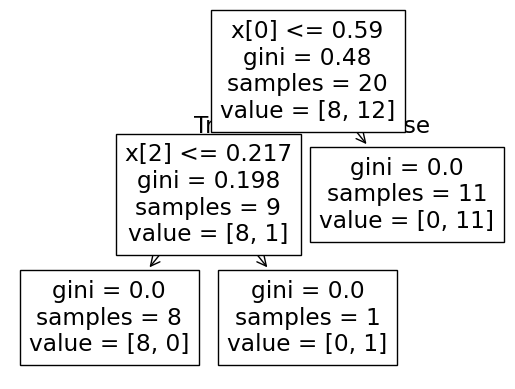

In [105]:
plot_tree(clf1)

[Text(0.6, 0.875, 'x[0] <= 1.038\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.4, 0.625, 'x[0] <= 0.309\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6, 0.375, 'x[0] <= 0.732\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.7, 0.75, '  False')]

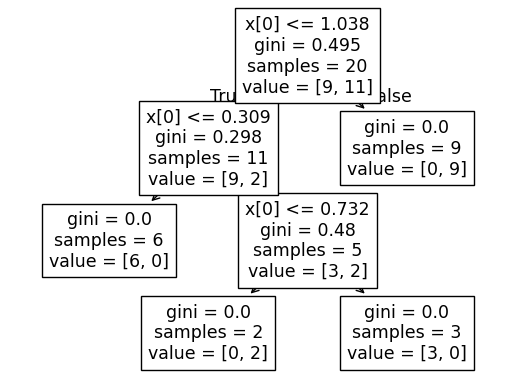

In [106]:
plot_tree(clf2)

[Text(0.3333333333333333, 0.875, 'x[0] <= -0.301\ngini = 0.48\nsamples = 20\nvalue = [12, 8]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= -0.96\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.375, 'x[2] <= 1.291\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

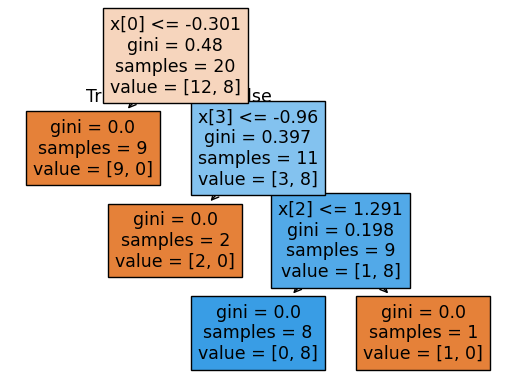

In [113]:
plot_tree(clf3,filled=True)

In [109]:
clf1.predict(np.array([-2.300186,-0.459194,-0.739565,2.201367,0.055104]).reshape(1,5))

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [111]:
clf2.predict(np.array([-2.300186,-0.459194,-0.739565,2.201367,0.055104]).reshape(1,5))

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [112]:
clf3.predict(np.array([-2.300186,-0.459194,-0.739565,2.201367,0.055104]).reshape(1,5))

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])